Compare repetition-centered lag-CRP curves for observed data and a matched control dataset.

Adjust `control_trial_query` to define alternative control populations.

Set `repetition_index` to 0 or 1 to focus on specific presentations.


In [1]:
import matplotlib.pyplot as plt
import os

from jaxcmr.analyses.repcrp import (
    plot_rep_crp,
    subject_rep_crp,
    test_first_second_bias,
    test_rep_crp_vs_control,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.repetition import make_control_dataset
def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()


In [2]:
data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
mixed_trial_query = "data['list_type'] > 2"
control_trial_query = "data['list_type'] == 1"
control_shuffles = 10
min_lag = 4
max_lag = 5
size = 2


In [3]:
# Parameters
data_path = "projects/repfr/results/simulations/Lohnas2025_BasePositionalCMRNoStop_rerun_best_of_1.h5"
figure_dir = "projects/repfr/results/figures/fitting"
figure_str = "Lohnas2025_BasePositionalCMRNoStop_rerun_best_of_1_repcrp.png"
mixed_trial_query = "data['list_type'] == 2"
control_trial_query = "data['list_type'] == 1"
control_shuffles = 1
ylim = [0.05, 0.32]


In [4]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, mixed_trial_query)
control_dataset = make_control_dataset(data, mixed_trial_query, control_trial_query, control_shuffles)
control_mask = generate_trial_mask(control_dataset, mixed_trial_query)
datasets = [data, control_dataset]
masks = [trial_mask, control_mask]


ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py", line 577, in shell_channel_thread_main
    _, msg2 = self.session.feed_identities(msg, copy=False)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/jupyter_client/session.py", line 993, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py", 

/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


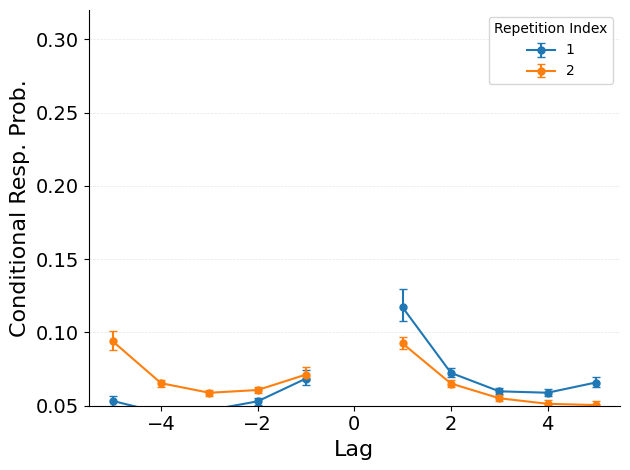

/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


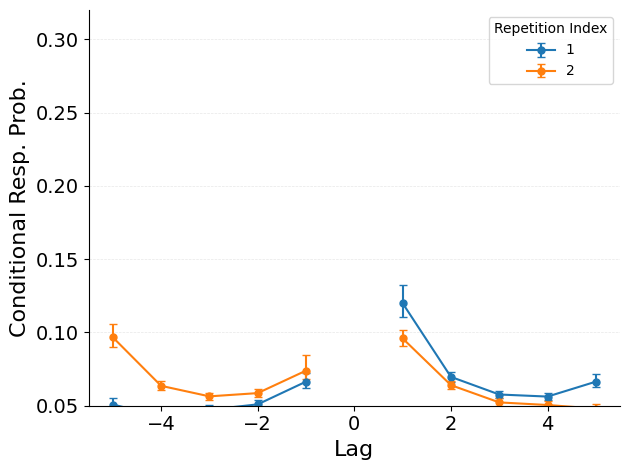

In [5]:
plot_rep_crp(
    datasets=data,
    trial_masks=trial_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    size=size,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str, suffix="mixed")
plot_rep_crp(
    datasets=control_dataset,
    trial_masks=control_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    size=size,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str, suffix="control")


In [6]:
observed_crp = subject_rep_crp(data, trial_mask, min_lag, max_lag, size)
control_crp = subject_rep_crp(control_dataset, control_mask, min_lag, max_lag, size)

results = test_rep_crp_vs_control(observed_crp, control_crp, max_lag)
for label, result in results.items():
    print(f"\n{'='*60}")
    print(f"Statistical Tests: {label}")
    print(f"{'='*60}")
    print(result)


Statistical Tests: First Presentation
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
   -5 |    1.714     0.0874 |  22708.0     0.0048 |     0.0027
   -4 |    2.357     0.0190 |  23692.0     0.0096 |     0.0025
   -3 |   -0.036     0.9714 |  27474.0     0.7073 |    -0.0000
   -2 |    1.899     0.0584 |  24323.0     0.0253 |     0.0020
   -1 |    1.354     0.1766 |  26259.0     0.2890 |     0.0021
    0 |      nan        nan |      nan        nan |        nan
    1 |   -1.799     0.0729 |  24514.0     0.0410 |    -0.0033
    2 |    2.053     0.0408 |  25444.0     0.0902 |     0.0028
    3 |    2.126     0.0342 |  24142.0     0.0154 |     0.0025
    4 |    2.093     0.0371 |  23826.0     0.0119 |     0.0028
    5 |   -0.315     0.7527 |  27803.0     0.7769 |    -0.0006

Statistical Tests: Second Presentation
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+------

/Users/jordangunn/jaxcmr/jaxcmr/analyses/repcrp.py:507: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, t_pval = stats.ttest_rel(obs_col, ctrl_col, nan_policy="omit")
/Users/jordangunn/jaxcmr/jaxcmr/analyses/repcrp.py:518: RuntimeWarning: Mean of empty slice
  mean_diffs[lag_idx] = np.nanmean(diff)


In [7]:
bias_result = test_first_second_bias(observed_crp, control_crp, max_lag)
print(f"\n{'='*70}")
print("Test: First-Second Bias (Observed) vs First-Second Bias (Control)")
print(f"{'='*70}")
print("H0: The preference for first-presentation neighbors over second-presentation")
print("    neighbors is the same in observed data as in the shuffled control.")
print()
print(bias_result)


Test: First-Second Bias (Observed) vs First-Second Bias (Control)
H0: The preference for first-presentation neighbors over second-presentation
    neighbors is the same in observed data as in the shuffled control.

  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
   -5 |    1.832     0.0678 |  24150.0     0.0196 |     0.0051
   -4 |    0.329     0.7426 |  26741.0     0.3792 |     0.0006
   -3 |   -1.511     0.1317 |  25673.0     0.1173 |    -0.0027
   -2 |   -0.177     0.8595 |  27739.0     0.6803 |    -0.0003
   -1 |    1.380     0.1684 |  27778.0     0.6963 |     0.0050
    0 |      nan        nan |      nan        nan |        nan
    1 |   -0.084     0.9332 |  27380.0     0.6025 |    -0.0002
    2 |    0.785     0.4331 |  26732.0     0.3297 |     0.0014
    3 |   -0.245     0.8063 |  28376.0     0.9552 |    -0.0004
    4 |    1.066     0.2872 |  26460.0     0.2599 |     0.0019
    5 |   -1.343     0.18

/Users/jordangunn/jaxcmr/jaxcmr/analyses/repcrp.py:576: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, t_pval = stats.ttest_rel(obs_d, ctrl_d, nan_policy="omit")
/Users/jordangunn/jaxcmr/jaxcmr/analyses/repcrp.py:587: RuntimeWarning: Mean of empty slice
  mean_diffs[lag_idx] = np.nanmean(diff_of_diff)
